# Section 1: Data Verification

| # | Figure | Description |
|---|--------|-------------|
| 1 | Trial inventory | Original vs preprocessed trial counts, missing blocks, split distribution |
| 2 | Trial count summary | Bar chart of DBS-OFF / DBS-ON trial counts per session |
| 3-6 | PSD DBS comparison | Power spectral density per ECoG channel, 4 sessions |
| 7 | Tracing speed DBS comparison | Mean velocity & acceleration traces by DBS condition |

In [1]:
import sys, os

os.chdir("/home/bobby/repos/latent-neural-dynamics-modeling")
sys.path.insert(0, ".")
sys.path.insert(0, "notebooks")

In [2]:
from collections import namedtuple
from pathlib import Path
import numpy as np
import polars as pl
import yaml
import matplotlib.pyplot as plt
from scipy.signal import welch

from thesis_style import (
    COLOR_DBS_OFF,
    COLOR_DBS_ON,
    COLOR_DPAD,
    COLOR_PSID,
    apply_thesis_style,
    hex_to_rgba,
    panel_label,
    stack_bar_label,
)

apply_thesis_style()

In [3]:
OUT = Path("thesis_figures/sec1")
OUT.mkdir(parents=True, exist_ok=True)
results_root = Path("results").resolve()
# PSD cells read the raw pre-split parquets — current per-session PSID variants
# only keep a selected subset of neural bands, so the split parquets no longer
# contain all 4 ECoG channels or the Laplacian contacts used by the PSD cells.
raw_data_root = Path(
    "resampled_recordings/participants_at_200Hz_scaled_1e6_narrow_band"
)
ECOG_CHANNELS = ["ECOG_1", "ECOG_2", "ECOG_3", "ECOG_4"]

In [4]:
# Session registry — auto-discovered via discover_session_run.
from thesis_loaders import discover_session_run, EXP_BEHAVIORAL, SESSIONS as _SESSION_NAMES

SessionSpec = namedtuple(
    "SessionSpec", ["label", "participant", "session", "psid_variant", "psid_run_ts"]
)

SESSIONS = []
for _name in _SESSION_NAMES:
    _var, _ts = discover_session_run(results_root, "psid", EXP_BEHAVIORAL, _name)
    if not _var:
        continue
    _pid, _sess = _name.split("_S")
    SESSIONS.append(SessionSpec(
        label=_name,
        participant=_pid,
        session=int(_sess),
        psid_variant=_var,
        psid_run_ts=_ts,
    ))

In [5]:
from scipy.signal import welch
from scipy.stats import mannwhitneyu
import matplotlib.cm as cm

FS_SPLIT = 200
MARGIN_S = 2
MARGIN_SAMP = MARGIN_S * FS_SPLIT
ECOG_CHANNELS = [1, 2, 3, 4]
LAP_CHANNEL_NAMES = ["8-10", "9-11", "10-12", "11-13", "12-14", "13-15", "14-16"]
raw_data_root = Path(
    "resampled_recordings/participants_at_200Hz_scaled_1e6_narrow_band"
)

def _session_raw_files(participant, session):
    return sorted(
        (raw_data_root / f"participant_id={participant}" / f"session={session}").glob(
            "*/*.parquet"
        )
    )

## DBS significance heatmap (sessions × frequency)

Computing ECoG band p-values...


Computing Laplacian band p-values...


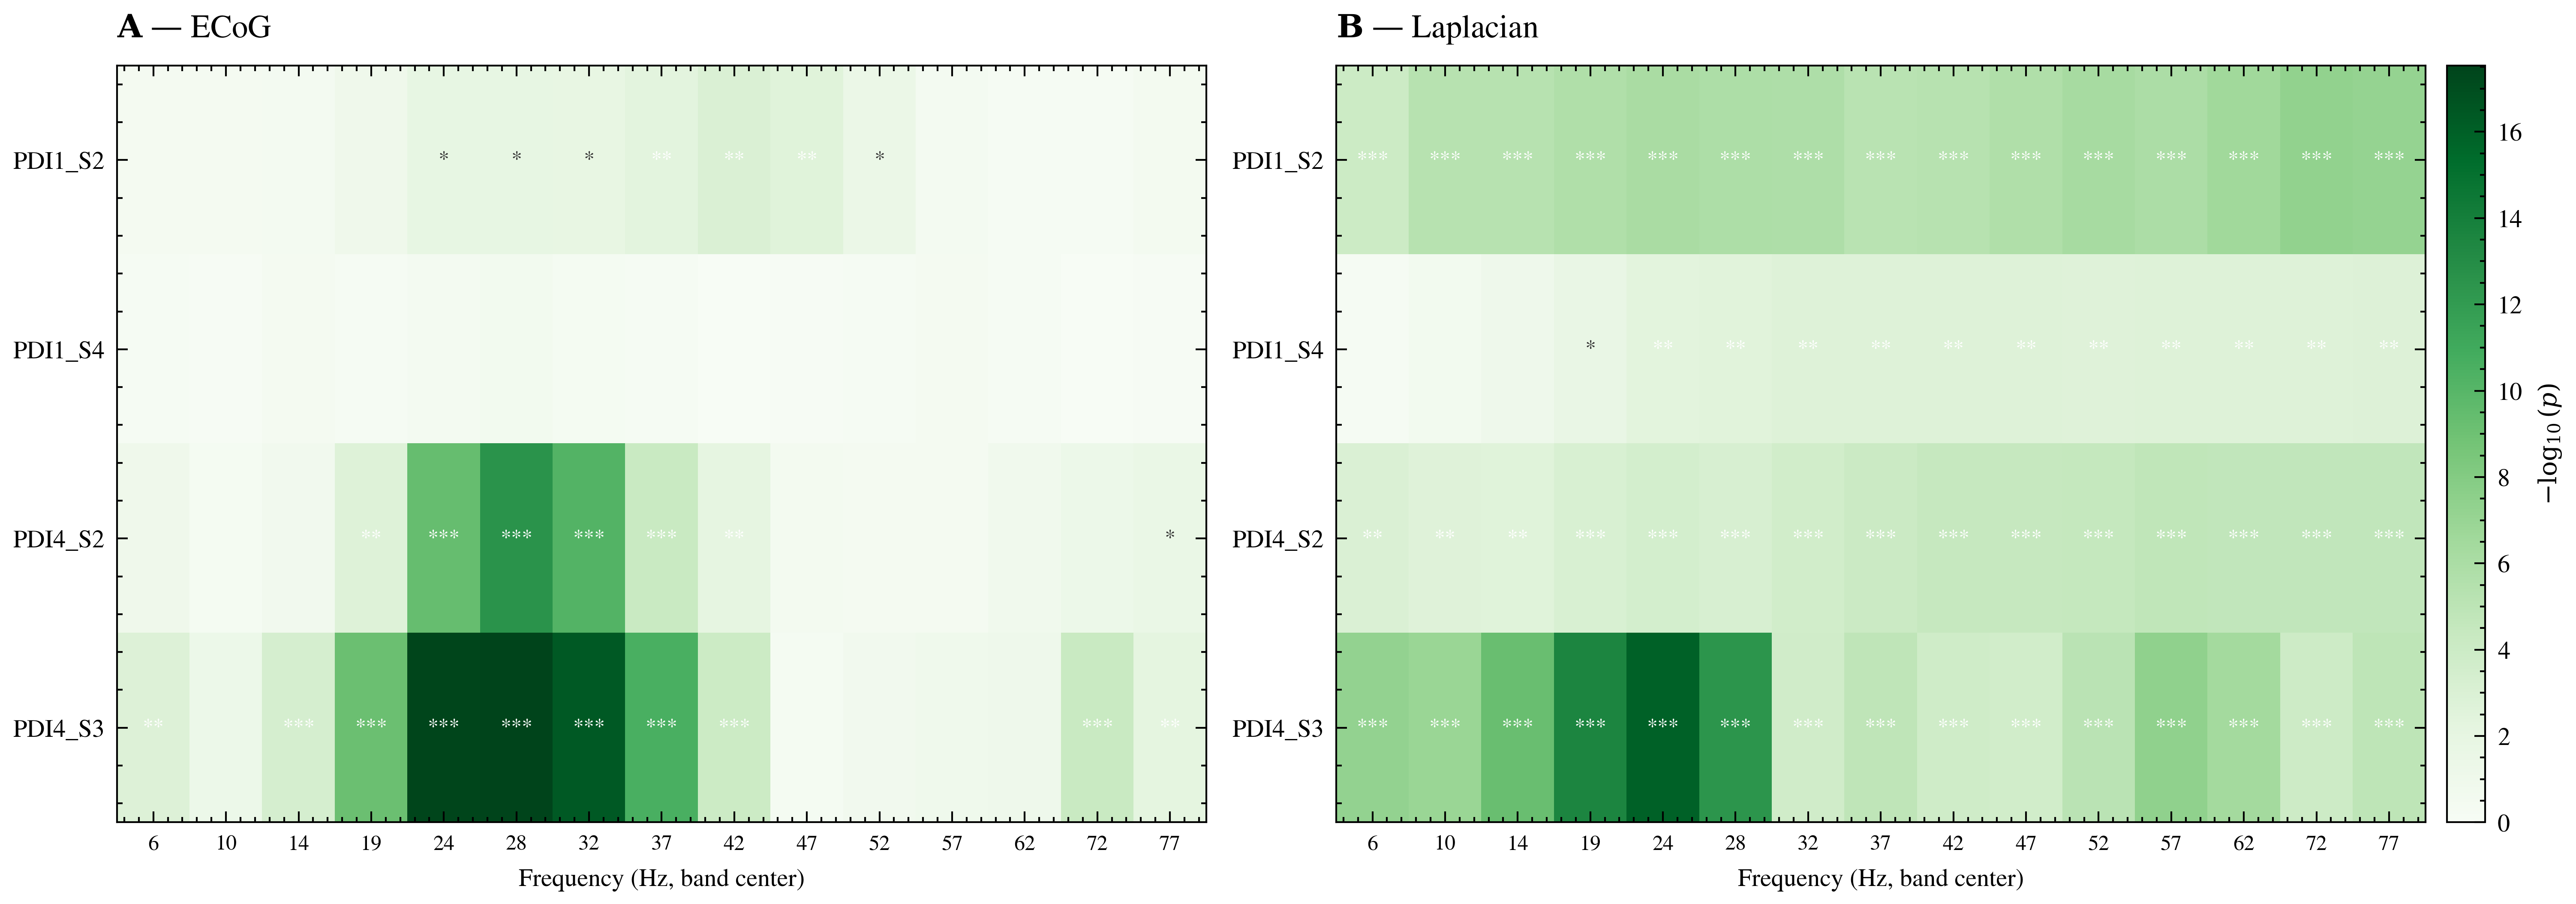

Saved -> fig_006_dbs_significance_heatmap.png


In [6]:
# DBS significance heatmap — ECoG (mean across 4 channels) + Laplacian (mean across 7 channels).
from scipy.stats import mannwhitneyu

BAND_ORDER = [
    ("theta_4_8", 4, 8),
    ("alpha_8_12", 8, 12),
    ("beta_12_17", 12, 17),
    ("beta_17_22", 17, 22),
    ("beta_22_27", 22, 27),
    ("beta_27_30", 27, 30),
    ("gamma_30_35", 30, 35),
    ("gamma_35_40", 35, 40),
    ("gamma_40_45", 40, 45),
    ("gamma_45_50", 45, 50),
    ("gamma_50_55", 50, 55),
    ("gamma_55_60", 55, 60),
    ("gamma_60_65", 60, 65),
    ("gamma_70_75", 70, 75),
    ("gamma_75_80", 75, 80),
]


def _compute_band_pvals(channel_prefix):
    n_bands = len(BAND_ORDER)
    pmat = np.full((len(SESSIONS), n_bands), np.nan)
    cols_needed = ["stim"] + [f"{channel_prefix}{bn}_raw" for bn, _, _ in BAND_ORDER]
    for si, s in enumerate(SESSIONS):
        off_powers, on_powers = [], []
        for fp in _session_raw_files(s.participant, s.session):
            df = pl.read_parquet(fp, columns=cols_needed)
            for row in df.iter_rows(named=True):
                cond = "off" if row["stim"] in ("off", "0") else "on"
                powers = []
                for bn, _, _ in BAND_ORDER:
                    arr = np.array(row[f"{channel_prefix}{bn}_raw"], dtype=float)
                    arr = arr[MARGIN_SAMP:-MARGIN_SAMP]
                    powers.append(np.nanmean(arr**2))
                (off_powers if cond == "off" else on_powers).append(powers)
        if len(off_powers) < 2 or len(on_powers) < 2:
            continue
        off_a, on_a = np.array(off_powers), np.array(on_powers)
        for bi in range(n_bands):
            try:
                _, p = mannwhitneyu(off_a[:, bi], on_a[:, bi], alternative="two-sided")
                pmat[si, bi] = -np.log10(max(p, 1e-20))
            except ValueError:
                pass
    return pmat


print("Computing ECoG band p-values...")
_ecog_pmats = [_compute_band_pvals(f"ECOG_{ch}_") for ch in ECOG_CHANNELS]
pmat_ecog = np.nanmean(np.stack(_ecog_pmats), axis=0)

print("Computing Laplacian band p-values...")
_lap_pmats = [_compute_band_pvals(f"LAPLACIAN_{name}_LFP_") for name in LAP_CHANNEL_NAMES]
pmat_lap = np.nanmean(np.stack(_lap_pmats), axis=0)

sess_labels = [s.label for s in SESSIONS]
band_centers = [f"{int((lo + hi) / 2)}" for _, lo, hi in BAND_ORDER]
global_vmax = max(np.nanmax(pmat_ecog), np.nanmax(pmat_lap))

fig, (ax_ecog, ax_lap) = plt.subplots(1, 2, figsize=(10.0, 3.5), layout="constrained")

for ax, pm, letter, title in [
    (ax_ecog, pmat_ecog, "A", "ECoG"),
    (ax_lap,  pmat_lap,  "B", "Laplacian"),
]:
    pm_disp = np.where(np.isfinite(pm), pm, 0)
    im = ax.imshow(
        pm_disp, aspect="auto", cmap="Greens",
        vmin=0, vmax=global_vmax, interpolation="nearest",
    )
    ax.set_xticks(range(len(BAND_ORDER)))
    ax.set_xticklabels(band_centers, fontsize=6)
    ax.set_yticks(range(len(sess_labels)))
    ax.set_yticklabels(sess_labels)
    ax.set_xlabel("Frequency (Hz, band center)")
    panel_label(ax, letter, title)
    for si in range(len(SESSIONS)):
        for bi in range(len(BAND_ORDER)):
            val = pm[si, bi]
            if not np.isfinite(val):
                continue
            if val > 3:
                ax.text(bi, si, "***", ha="center", va="center", fontsize=6, color="white")
            elif val > 2:
                ax.text(bi, si, "**",  ha="center", va="center", fontsize=6, color="white")
            elif val > -np.log10(0.05):
                ax.text(bi, si, "*",   ha="center", va="center", fontsize=6, color="#333")

fig.colorbar(im, ax=ax_lap, label=r"$-\log_{10}(p)$", fraction=0.05, pad=0.02)
fig.savefig(str(OUT / "fig_006_dbs_significance_heatmap.png"))
plt.show()
print("Saved -> fig_006_dbs_significance_heatmap.png")

## Spectral separability — per-session DBS modulation profile

Line profiles of -log10(p) across frequency bands. PDI1 sessions (dashed, gray) show little DBS modulation; PDI4 sessions (solid, blue) show clear gamma-band separation. Explains why PDI1 decoding sits at chance throughout all RQs.

/tmp/ipykernel_570315/2211034811.py:29: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


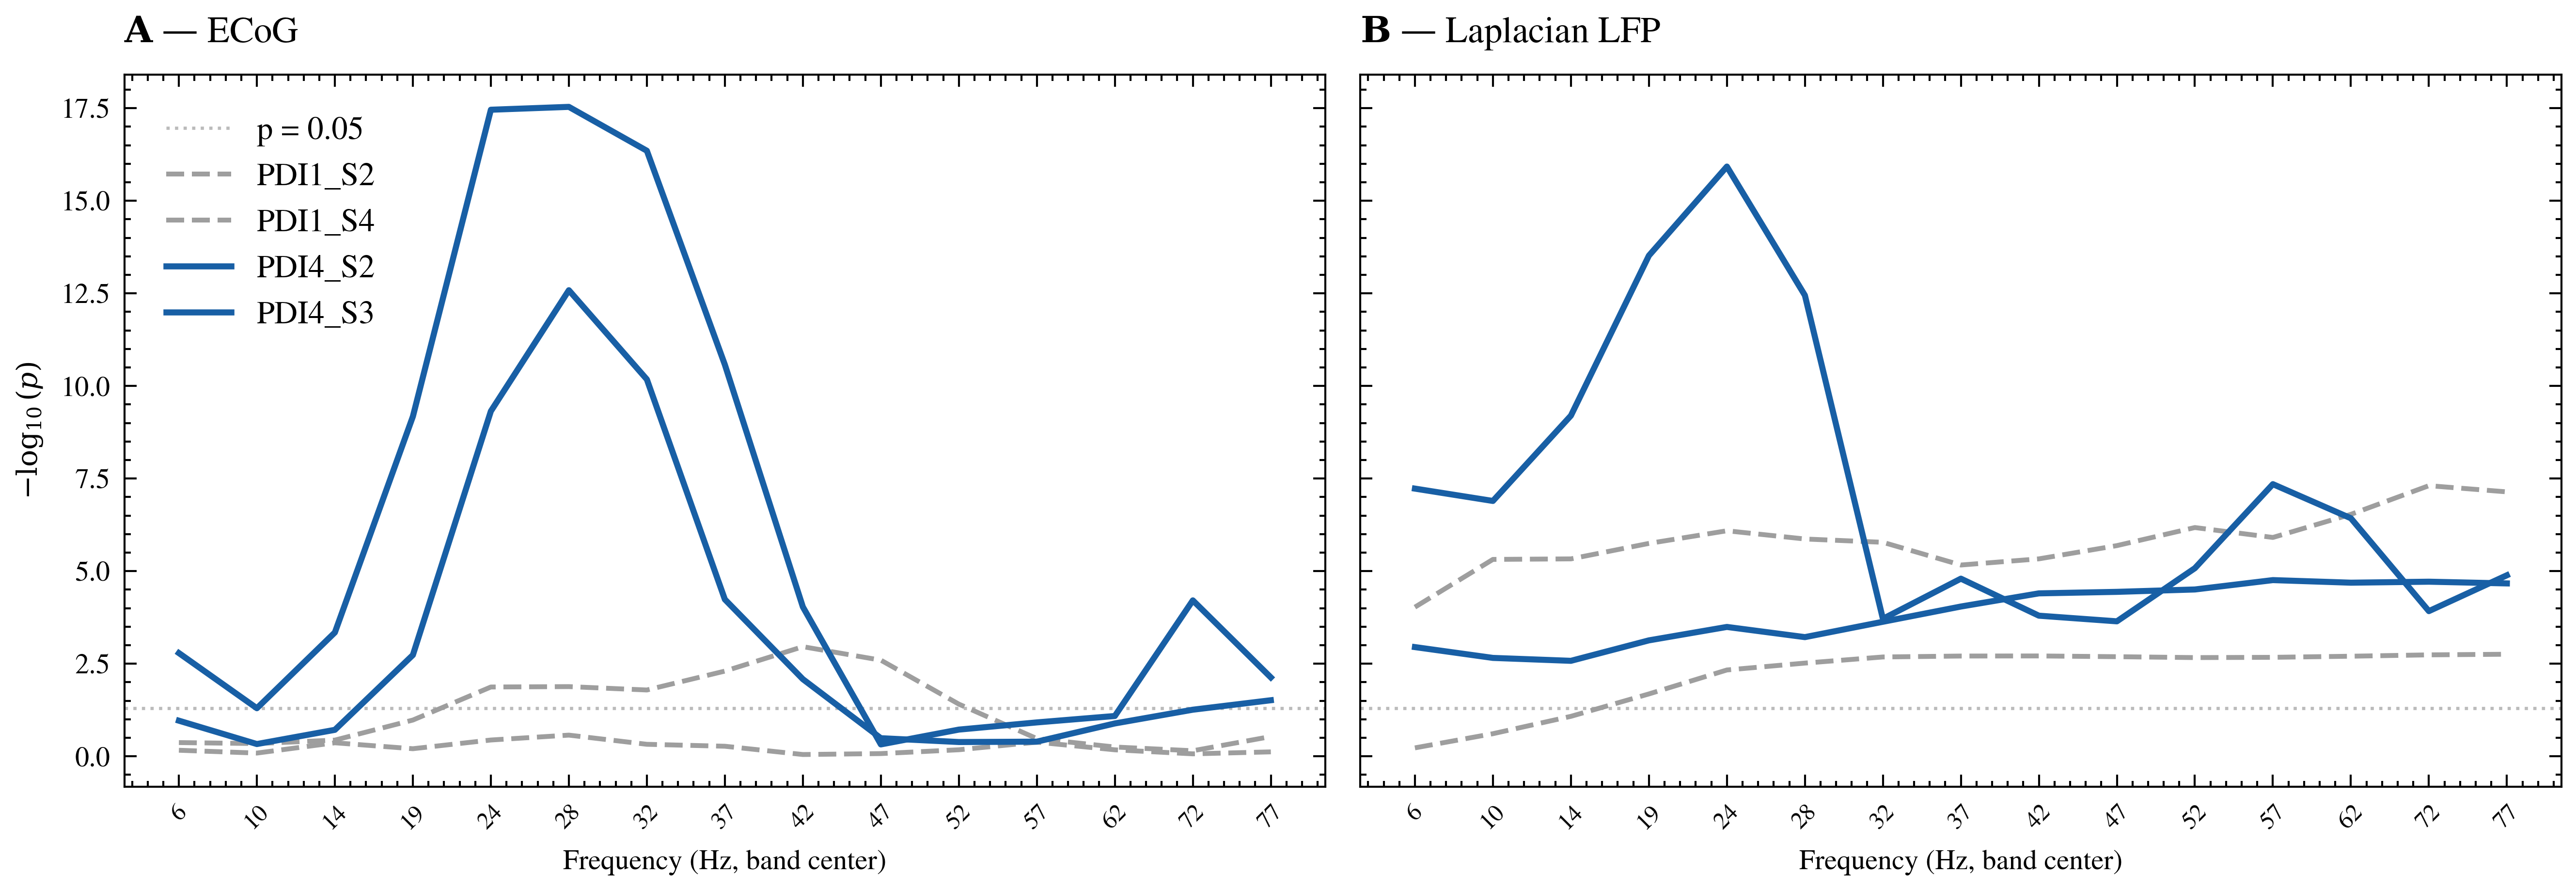

Saved -> fig_spectral_separability.png


In [7]:
# Spectral separability — reuses pmat_ecog / pmat_lap from heatmap cell above
THRESH = -np.log10(0.05)
x = np.arange(len(BAND_ORDER))
freq_labels = [f"{int((lo + hi) / 2)}" for _, lo, hi in BAND_ORDER]

PART_STYLE = {
    "PDI1": {"color": "#9E9E9E", "ls": "--", "lw": 1.2},
    "PDI4": {"color": COLOR_PSID,  "ls": "-",  "lw": 1.5},
}

fig, (ax_e, ax_l) = plt.subplots(1, 2, figsize=(9.0, 3.2), sharey=True)

for ax, pm, letter, title in [
    (ax_e, pmat_ecog, "A", "ECoG"),
    (ax_l, pmat_lap,  "B", "Laplacian LFP"),
]:
    ax.axhline(THRESH, color="#bbb", lw=0.8, ls=":", label="p = 0.05")
    for si, sl in enumerate(sess_labels):
        part = sl.split("_")[0]
        style = PART_STYLE[part]
        ax.plot(x, pm[si], label=sl, **style)
    ax.set_xticks(x)
    ax.set_xticklabels(freq_labels, fontsize=6, rotation=45)
    ax.set_xlabel("Frequency (Hz, band center)")
    panel_label(ax, letter, title)

ax_e.set_ylabel(r"$-\log_{10}(p)$")
ax_e.legend(loc="upper left")
fig.tight_layout()
fig.savefig(str(OUT / "fig_spectral_separability.png"))
plt.show()
print("Saved -> fig_spectral_separability.png")